## 3 — GLMER-MRP
Frequentist 3-level hierarchical logistic regression (penalised ML) — Howe (2015) architecture.

**Individual level:** `logit(p_i) = γ₀ + α_gender[g] + α_race[r] + α_educ[e] + α_state[s]`

**State level:**
`α_state[s] ~ N(α_region[div[s]] + γ_carbon·co2 + γ_pres·pres + γ_drive·drive + γ_samesex·samesex, σ_state²)`

**Region level:** `α_region[r] ~ N(0, σ_region²)` — 9 Census divisions

Estimation: L-BFGS-B MAP with **diffuse priors** (σ_prior = 10, equivalent to penalised ML).  
Compare with `4_GLMERStan` which uses proper Bayesian priors (σ_prior = 2.5).

Output: `outputs/estimates/glmer_mrp_state_estimates.csv`

In [10]:
import warnings
warnings.filterwarnings("ignore")

import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.special import expit
from scipy.optimize import minimize

DATA_DIR   = Path("../test_data/processed/")
RAW_DIR    = Path("../test_data/raw/")
OUTPUT_DIR = Path("../outputs/")
OUTCOME    = "happening_bin"
MODEL_NAME = "glmer_mrp"

STATE_NAMES = {
    "01":"Alabama","02":"Alaska","04":"Arizona","05":"Arkansas","06":"California",
    "08":"Colorado","09":"Connecticut","10":"Delaware","11":"District of Columbia",
    "12":"Florida","13":"Georgia","15":"Hawaii","16":"Idaho","17":"Illinois",
    "18":"Indiana","19":"Iowa","20":"Kansas","21":"Kentucky","22":"Louisiana",
    "23":"Maine","24":"Maryland","25":"Massachusetts","26":"Michigan",
    "27":"Minnesota","28":"Mississippi","29":"Missouri","30":"Montana",
    "31":"Nebraska","32":"Nevada","33":"New Hampshire","34":"New Jersey",
    "35":"New Mexico","36":"New York","37":"North Carolina","38":"North Dakota",
    "39":"Ohio","40":"Oklahoma","41":"Oregon","42":"Pennsylvania",
    "44":"Rhode Island","45":"South Carolina","46":"South Dakota",
    "47":"Tennessee","48":"Texas","49":"Utah","50":"Vermont",
    "51":"Virginia","53":"Washington","54":"West Virginia","55":"Wisconsin",
    "56":"Wyoming",
}

In [11]:
# ── Load state-level covariates ───────────────────────────────────────────────
carbon  = pd.read_csv(RAW_DIR / "carbon_state.csv",  dtype={"state_fips": str})[["state_fips","co2_per_capita"]]
pres    = pd.read_csv(RAW_DIR / "pres_state.csv",    dtype={"state_fips": str})[["state_fips","dem_share_two_party"]]
acs_ext = pd.read_csv(DATA_DIR / "acs_state_extra_covariates.csv", dtype={"state_fips": str})

state_cov = carbon.merge(pres, on="state_fips").merge(acs_ext, on="state_fips")

# ── Load survey ───────────────────────────────────────────────────────────────
ps_raw = pd.read_csv(DATA_DIR / "poststrat_state.csv", dtype={"state_fips": str})
survey = pd.read_csv(DATA_DIR / "climate_survey_responses_recoded.csv", dtype={"state_fips": str})
survey = survey.dropna(subset=[OUTCOME]).copy()
survey[OUTCOME] = survey[OUTCOME].astype(float)
survey["educ_category"] = survey["educ_category"].astype(str)

print(f"Survey: {len(survey):,}  ({survey[OUTCOME].mean()*100:.1f}% Yes)")
print(f"Poststrat: {ps_raw.shape} | {ps_raw['state_fips'].nunique()} states")

Survey: 1,012  (69.1% Yes)
Poststrat: (1632, 9) | 51 states


In [12]:
# ── State-level covariate arrays ──────────────────────────────────────────────
state_cats = sorted(survey["state_fips"].unique())
div_cats   = sorted(ps_raw["division"].unique())
n_div      = len(div_cats)

# Impute 4 states with missing county data using national mean
for col in ["co2_per_capita","dem_share_two_party"]:
    state_cov[col] = state_cov[col].fillna(state_cov[col].mean())

sc = state_cov.set_index("state_fips").loc[state_cats].reset_index()

def _std(x):
    return (x - x.mean()) / x.std()

co2_std     = _std(sc["co2_per_capita"].values)
pres_std    = _std(sc["dem_share_two_party"].values)
drive_std   = _std(sc["pct_drive_alone"].values)
samesex_std = _std(sc["pct_samesex_hh"].values)

div_per_state = ps_raw.groupby("state_fips")["division"].first()
state_div_idx = pd.Categorical(
    div_per_state.loc[state_cats].astype(str).values,
    categories=[str(d) for d in div_cats]
).codes

print(f"States: {len(state_cats)}  Divisions: {n_div}")
print(f"co2_std  range: [{co2_std.min():.2f}, {co2_std.max():.2f}]")
print(f"drive_std range: [{drive_std.min():.2f}, {drive_std.max():.2f}]")

States: 51  Divisions: 9
co2_std  range: [-0.97, 4.73]
drive_std range: [-5.12, 1.28]


In [13]:
# ── Integer-encode survey categorical variables ───────────────────────────────
gender_cats = sorted(survey["gender"].unique())
race_cats   = sorted(survey["race4"].unique())
educ_cats   = sorted(survey["educ_category"].unique())

g_idx = pd.Categorical(survey["gender"],          categories=gender_cats).codes
s_idx = pd.Categorical(survey["state_fips"],      categories=state_cats).codes
r_idx = pd.Categorical(survey["race4"],           categories=race_cats).codes
e_idx = pd.Categorical(survey["educ_category"],   categories=educ_cats).codes
y     = survey[OUTCOME].values.astype(float)

n_g, n_s, n_r, n_e = len(gender_cats), len(state_cats), len(race_cats), len(educ_cats)

print(f"gender:{n_g}  state:{n_s}  race:{n_r}  educ:{n_e}  div:{n_div}")
print(f"Total params: 1+5+4+{n_g}+{n_r}+{n_e}+{n_div}+{n_s} = {1+5+4+n_g+n_r+n_e+n_div+n_s}")

gender:2  state:51  race:4  educ:4  div:9
Total params: 1+5+4+2+4+4+9+51 = 80


### Fit — Howe (2015) 3-level MAP (diffuse priors = penalised ML)
Uses wide priors (σ_prior = 10) so regularisation is minimal — equivalent to  
penalised maximum likelihood rather than a full Bayesian posterior mode.  
Compare `4_GLMERStan` which uses `σ_prior = 2.5` (proper Bayesian shrinkage).

In [14]:
# ─── Diffuse-prior MAP (frequentist GLMER) ─────────────────────────────────────
SIGMA_PRIOR = 10.0   # wide = minimal shrinkage; GLMERStan uses 2.5

def _unpack(params):
    g0            = params[0]
    sigma         = np.exp(params[1:6])   # [σ_gender, σ_race, σ_educ, σ_state, σ_region]
    gc, gp, gd, gs = params[6], params[7], params[8], params[9]
    off = 10
    u_g   = params[off:off+n_g];   off += n_g
    u_r   = params[off:off+n_r];   off += n_r
    u_e   = params[off:off+n_e];   off += n_e
    u_reg = params[off:off+n_div]; off += n_div
    u_s   = params[off:off+n_s]
    return g0, sigma, gc, gp, gd, gs, u_g, u_r, u_e, u_reg, u_s

def neg_log_posterior(params):
    g0, sigma, gc, gp, gd, gs, u_g, u_r, u_e, u_reg, u_s = _unpack(params)
    sig_g, sig_r, sig_e, sig_s, sig_reg = sigma

    eta = g0 + u_g[g_idx] + u_r[r_idx] + u_e[e_idx] + u_s[s_idx]
    ll  = np.sum(y * eta - np.logaddexp(0.0, eta))

    mu_s = (u_reg[state_div_idx]
            + gc * co2_std + gp * pres_std
            + gd * drive_std + gs * samesex_std)
    lp_s   = -0.5 * np.sum((u_s - mu_s)**2) / sig_s**2   - n_s   * np.log(sig_s)
    lp_reg = -0.5 * np.sum(u_reg**2) / sig_reg**2         - n_div * np.log(sig_reg)
    lp_g   = -0.5 * np.sum(u_g**2) / sig_g**2  - n_g * np.log(sig_g)
    lp_r   = -0.5 * np.sum(u_r**2) / sig_r**2  - n_r * np.log(sig_r)
    lp_e   = -0.5 * np.sum(u_e**2) / sig_e**2  - n_e * np.log(sig_e)

    lp_int   = -0.5 * g0**2 / SIGMA_PRIOR**2
    lp_gamma = -0.5 * (gc**2 + gp**2 + gd**2 + gs**2) / SIGMA_PRIOR**2
    lp_sigma = np.sum(-0.5 * sigma**2 / SIGMA_PRIOR**2 + params[1:6])

    return -(ll + lp_s + lp_reg + lp_g + lp_r + lp_e + lp_int + lp_gamma + lp_sigma)

N_PARAMS = 1 + 5 + 4 + n_g + n_r + n_e + n_div + n_s
x0 = np.zeros(N_PARAMS)
x0[1:6] = np.log(0.5)

start = time.time()
res   = minimize(neg_log_posterior, x0, method="L-BFGS-B",
                 options={"maxiter": 20_000, "ftol": 1e-9, "gtol": 1e-6})
elapsed = time.time() - start

g0_fit, sigma_fit, gc_fit, gp_fit, gd_fit, gs_fit, u_g_fit, u_r_fit, u_e_fit, u_reg_fit, u_s_fit = _unpack(res.x)

print(f"Converged : {res.success}  |  iterations: {res.nit}  |  {elapsed:.1f}s")
print(f"Intercept : {g0_fit:.3f}  (baseline prob {expit(g0_fit)*100:.1f}%)")
print(f"γ_carbon  : {gc_fit:.3f}  γ_pres : {gp_fit:.3f}  γ_drive : {gd_fit:.3f}  γ_samesex : {gs_fit:.3f}")
print(f"σ — gender:{sigma_fit[0]:.3f}  race:{sigma_fit[1]:.3f}  educ:{sigma_fit[2]:.3f}  "
      f"state:{sigma_fit[3]:.3f}  region:{sigma_fit[4]:.3f}")
print(f"State effect range: [{u_s_fit.min():.3f}, {u_s_fit.max():.3f}]")

Converged : True  |  iterations: 106  |  1.4s
Intercept : 1.078  (baseline prob 74.6%)
γ_carbon  : 0.073  γ_pres : 0.427  γ_drive : 0.010  γ_samesex : -0.184
σ — gender:0.429  race:0.280  educ:0.296  state:0.000  region:0.087
State effect range: [-0.489, 0.542]


In [15]:
# ── Predict on poststrat frame ────────────────────────────────────────────────
ps = ps_raw[["state_fips","gender","race4","educ_category","N_rounded"]].copy()
ps["educ_category"] = ps["educ_category"].astype(str)

ps_g = pd.Categorical(ps["gender"],          categories=gender_cats).codes
ps_s = pd.Categorical(ps["state_fips"],      categories=state_cats).codes
ps_r = pd.Categorical(ps["race4"],           categories=race_cats).codes
ps_e = pd.Categorical(ps["educ_category"],   categories=educ_cats).codes

eta_ps = g0_fit + u_g_fit[ps_g] + u_r_fit[ps_r] + u_e_fit[ps_e] + u_s_fit[ps_s]
ps["predicted_prob"] = expit(eta_ps)

print(f"Predicted probs: min={ps['predicted_prob'].min():.3f}  "
      f"mean={ps['predicted_prob'].mean():.3f}  max={ps['predicted_prob'].max():.3f}")

Predicted probs: min=0.280  mean=0.785  max=0.997


In [16]:
# ── Poststratify ──────────────────────────────────────────────────────────────
estimates = (
    ps.groupby("state_fips")
    .apply(lambda g: np.average(g["predicted_prob"], weights=g["N_rounded"]),
           include_groups=False)
    .reset_index(name="estimate")
)
estimates["state_name"] = estimates["state_fips"].map(STATE_NAMES)
n_resp = survey.groupby("state_fips")[OUTCOME].count().reset_index(name="n_respondents")
estimates = estimates.merge(n_resp, on="state_fips", how="left")
estimates["n_respondents"] = estimates["n_respondents"].fillna(0).astype(int)
estimates = estimates.sort_values("estimate", ascending=False).reset_index(drop=True)

print(f"National mean: {estimates['estimate'].mean():.4f}")
print("\nTop 5:"); print(estimates.head(5).to_string(index=False))
print("\nBottom 5:"); print(estimates.tail(5).to_string(index=False))

National mean: 0.7400

Top 5:
state_fips  estimate           state_name  n_respondents
        11  0.945190 District of Columbia              3
        24  0.867851             Maryland             15
        17  0.832722             Illinois             40
        15  0.820507               Hawaii              5
        34  0.816957           New Jersey             24

Bottom 5:
state_fips  estimate    state_name  n_respondents
        47  0.656054     Tennessee             13
        16  0.651911         Idaho              7
        40  0.633356      Oklahoma             10
        21  0.608648      Kentucky             18
        54  0.556688 West Virginia             12


In [17]:
est_dir  = OUTPUT_DIR / "estimates"
diag_dir = OUTPUT_DIR / "diagnostics"
est_dir.mkdir(parents=True, exist_ok=True)
diag_dir.mkdir(parents=True, exist_ok=True)

out_path = est_dir / f"{MODEL_NAME}_state_estimates.csv"
estimates.to_csv(out_path, index=False)
print(f"Saved → {out_path}")

valid = estimates.dropna(subset=["estimate"])
diag_path = diag_dir / f"{MODEL_NAME}_summary.txt"
with open(diag_path, "w") as f:
    f.write("GLMER-MRP (Howe 2015, penalised ML) — Diagnostic Summary\n" + "="*55 + "\n\n")
    f.write(f"Outcome: {OUTCOME}\n")
    f.write(f"Estimation: L-BFGS-B MAP with diffuse priors (sigma_prior={SIGMA_PRIOR})\n")
    f.write(f"Observations: {len(y):,}\n")
    f.write(f"Converged: {res.success}  iterations: {res.nit}  time: {elapsed:.1f}s\n\n")
    f.write(f"Intercept:  {g0_fit:.4f}\n")
    f.write(f"gamma_carbon:  {gc_fit:.4f}\n")
    f.write(f"gamma_pres:    {gp_fit:.4f}\n")
    f.write(f"gamma_drive:   {gd_fit:.4f}\n")
    f.write(f"gamma_samesex: {gs_fit:.4f}\n\n")
    f.write(f"Sigma_gender:  {sigma_fit[0]:.4f}\n")
    f.write(f"Sigma_race:    {sigma_fit[1]:.4f}\n")
    f.write(f"Sigma_educ:    {sigma_fit[2]:.4f}\n")
    f.write(f"Sigma_state:   {sigma_fit[3]:.4f}\n")
    f.write(f"Sigma_region:  {sigma_fit[4]:.4f}\n\n")
    f.write(f"State estimates — mean:{valid['estimate'].mean():.4f}  ")
    f.write(f"min:{valid['estimate'].min():.4f}  max:{valid['estimate'].max():.4f}\n\n")
    f.write("State-level estimates:\n")
    f.write(estimates.to_string(index=False))
print(f"Diagnostics → {diag_path}")

Saved → ../outputs/estimates/glmer_mrp_state_estimates.csv
Diagnostics → ../outputs/diagnostics/glmer_mrp_summary.txt


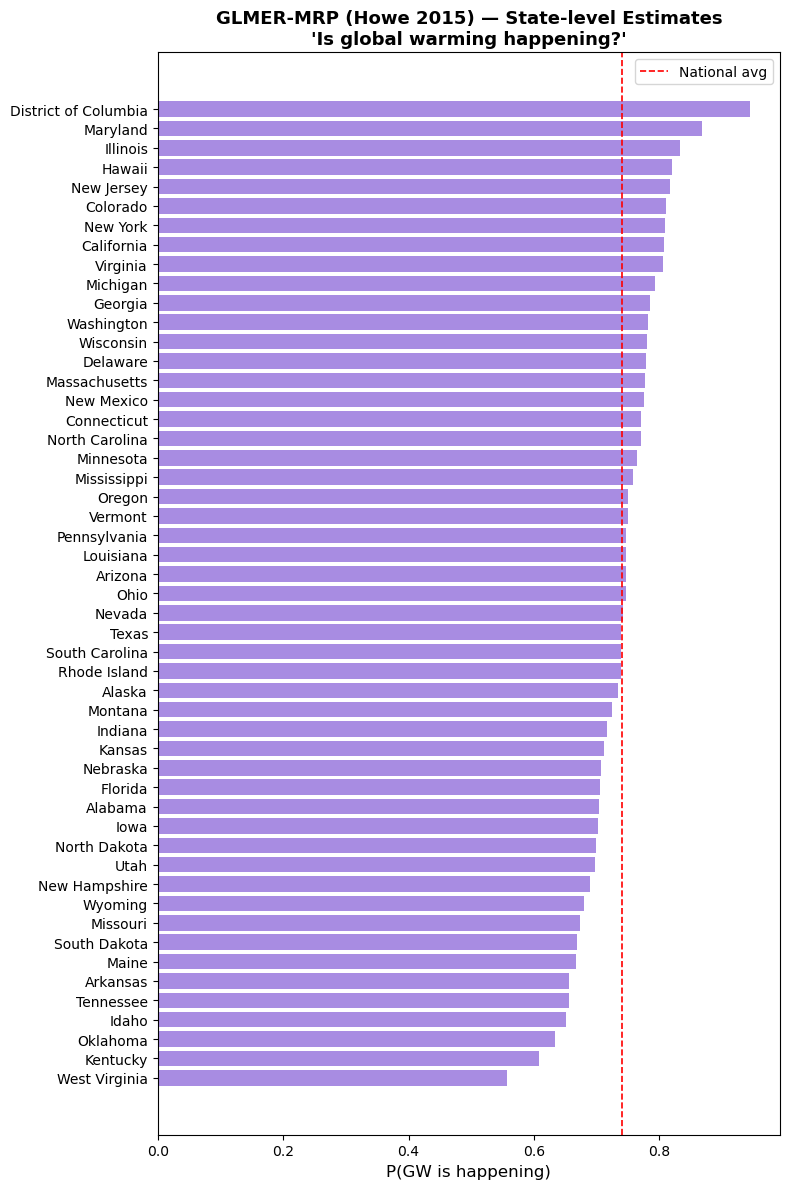

In [18]:
fig, ax = plt.subplots(figsize=(8, 12))
plot_df = estimates.sort_values("estimate")
ax.barh(plot_df["state_name"], plot_df["estimate"], color="mediumpurple", alpha=0.8)
ax.axvline(estimates["estimate"].mean(), color="red", linestyle="--", linewidth=1.2, label="National avg")
ax.set_xlabel("P(GW is happening)", fontsize=12)
ax.set_title("GLMER-MRP (Howe 2015) — State-level Estimates\n'Is global warming happening?'",
             fontsize=13, fontweight="bold")
ax.legend()
plt.tight_layout()
plt.savefig(est_dir / f"{MODEL_NAME}_state_estimates.png", dpi=150, bbox_inches="tight")
plt.show()